# Clasificador de perros y gatos con `transfer learning`

En este proyecto voy a construir un clasificador de imágenes para diferenciar `Gato` y `Perro`.

Primero voy a validar el problema con una `CNN` simple y una muestra pequeña. Después voy a probar una arquitectura reducida inspirada en `VGG` y finalmente voy a usar `transfer learning` con `MobileNetV2`.


## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

plt.style.use("./apple.mplstyle")

SEPARATOR = 120 * "-"

## 2. Dataset y estrategia de carga

El dataset completo tiene 25.000 imágenes. No lo voy a cargar entero en memoria.

Voy a trabajar con carpetas y `batches` pequeños usando `Keras`, porque en este equipo `TensorFlow` está funcionando por `CPU` y no por `GPU`.


In [2]:
data_dir = Path("../data/raw/dogs-vs-cats-sample")

train_dir = data_dir / "train"
validation_dir = data_dir / "validation"
test_dir = data_dir / "test"

for split_name, split_dir in [
    ("train", train_dir),
    ("validation", validation_dir),
    ("test", test_dir),
]:
    cat_images = list((split_dir / "cat").glob("*.jpg"))
    dog_images = list((split_dir / "dog").glob("*.jpg"))

    print(f"{split_name} - gatos: {len(cat_images)} imágenes")
    print(f"{split_name} - perros: {len(dog_images)} imágenes")

train - gatos: 200 imágenes
train - perros: 200 imágenes
validation - gatos: 50 imágenes
validation - perros: 50 imágenes
test - gatos: 50 imágenes
test - perros: 50 imágenes


## 3. Exploración visual inicial

### 3.1. Ejemplos de perros

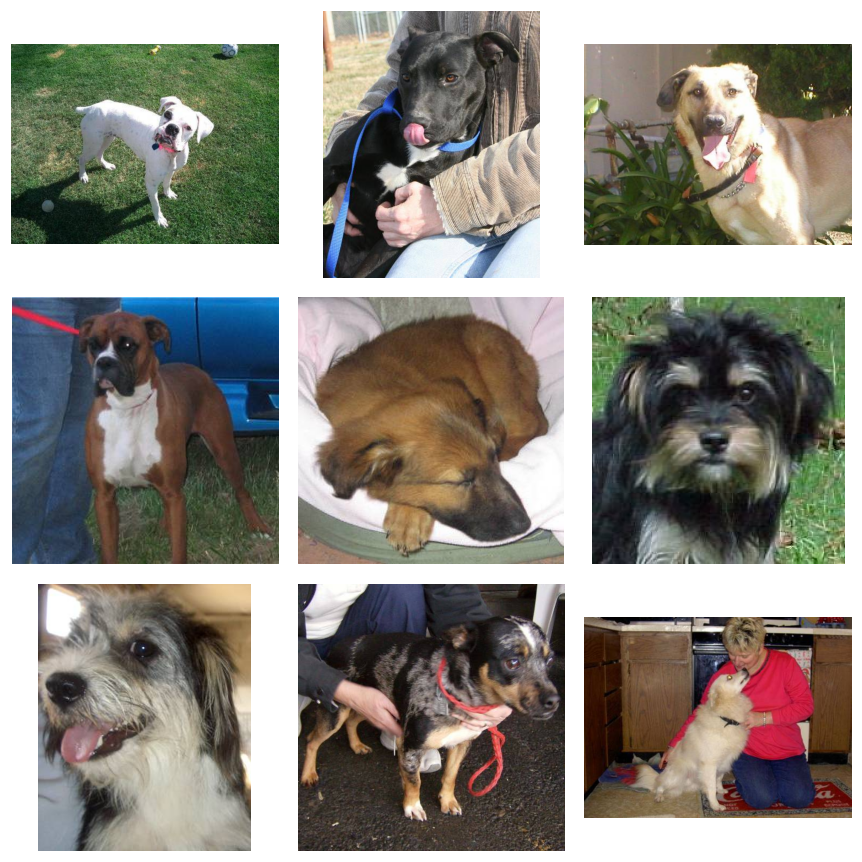

In [3]:
dog_images = list((train_dir / "dog").glob("*.jpg"))

plt.figure(figsize=(8, 8))

for index, image_path in enumerate(dog_images[:9]):
    image = Image.open(image_path)

    plt.subplot(3, 3, index + 1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 3.2. Ejemplos de gatos

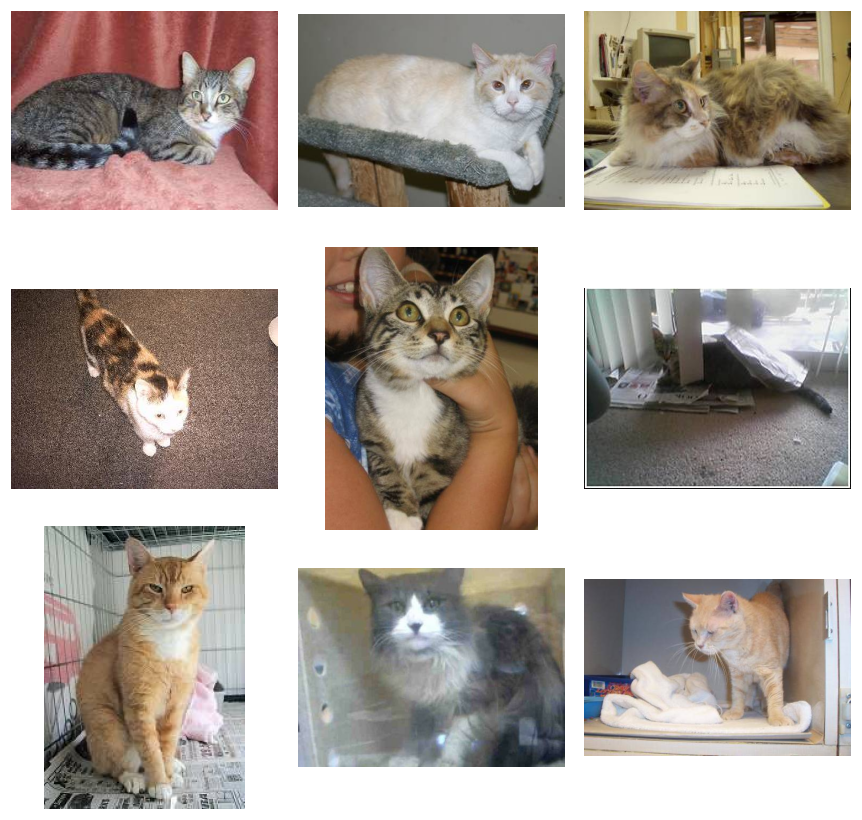

In [4]:
cat_images = list((train_dir / "cat").glob("*.jpg"))

plt.figure(figsize=(8, 8))

for index, image_path in enumerate(cat_images[:9]):
    image = Image.open(image_path)

    plt.subplot(3, 3, index + 1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Tamaños, canales y formato de las imágenes

Reviso si las imágenes tienen tamaños distintos y confirmo que son imágenes `RGB`. Esta revisión explica por qué necesitamos redimensionarlas antes de entrenar.


In [5]:
image_paths = list(train_dir.glob("*/*.jpg"))

image_info = []

for image_path in image_paths[:50]:
    image = Image.open(image_path)
    image_array = np.array(image)

    image_info.append({
        "Archivo": image_path.name,
        "Clase": image_path.parent.name,
        "Ancho": image.size[0],
        "Alto": image.size[1],
        "Canales": image_array.shape[2] if image_array.ndim == 3 else 1,

    })



image_info_df = pd.DataFrame(image_info)

display(image_info_df.head())

print(f"Cantidad de imágenes revisadas: {len(image_info_df)}")
print(SEPARATOR)

print("Tamaños más frecuentes:")
display(
    image_info_df[["Ancho", "Alto"]]
    .value_counts()
    .head(10)
)

print(SEPARATOR)

print("Canales encontrados:")
display(image_info_df["Canales"].value_counts())

,Archivo,Clase,Ancho,Alto,Canales
0,cat.10004.jpg,cat,320,239,3
1,cat.10044.jpg,cat,378,273,3
2,cat.10092.jpg,cat,359,268,3
3,cat.10166.jpg,cat,349,262,3
4,cat.10284.jpg,cat,375,499,3


Cantidad de imágenes revisadas: 50
------------------------------------------------------------------------------------------------------------------------
Tamaños más frecuentes:


Ancho  Alto
499    375     8
500    374     5
320    239     1
378    273     1
359    268     1
349    262     1
375    499     1
296    223     1
163    230     1
500    332     1
Name: count, dtype: int64

------------------------------------------------------------------------------------------------------------------------
Canales encontrados:


Canales
3    50
Name: count, dtype: int64

Las imágenes tienen tamaños distintos. Todas están en formato RGB con 3 canales.

Voy a redimensionarlas al mismo tamaño antes de entrenar la red neuronal.

## 5. Fase 1. Preparación de una muestra pequeña

In [6]:
image_size = (160, 160)
batch_size = 32

print(f"Tamaño final de cada imagen: {image_size}")
print(f"Tamaño de cada batch: {batch_size}")
print(SEPARATOR)

print(f"Carpeta de entrenamiento: {train_dir}")
print(f"Carpeta de validación: {validation_dir}")
print(f"Carpeta de test: {test_dir}")

Tamaño final de cada imagen: (160, 160)
Tamaño de cada batch: 32
------------------------------------------------------------------------------------------------------------------------
Carpeta de entrenamiento: ..\data\raw\dogs-vs-cats-sample\train
Carpeta de validación: ..\data\raw\dogs-vs-cats-sample\validation
Carpeta de test: ..\data\raw\dogs-vs-cats-sample\test


## 6. Fase 1. Generadores de `Keras`

Creo los datasets de entrenamiento, validación y test usando `batches`. Así `Keras` carga las imágenes en lotes desde disco.

In [7]:
train_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=True,
    seed=42,
)

validation_dataset = keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False,
)

test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False,
)

print(f"Clases detectadas: {train_dataset.class_names}")
print(SEPARATOR)

for images_batch, labels_batch in train_dataset.take(1):
    print(f"Forma del batch de imágenes: {images_batch.shape}")
    print(f"Forma del batch de etiquetas: {labels_batch.shape}")
    print(f"Etiquetas del primer batch: {labels_batch[:10].numpy().ravel()}")

Found 400 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Clases detectadas: ['cat', 'dog']
------------------------------------------------------------------------------------------------------------------------
Forma del batch de imágenes: (32, 160, 160, 3)
Forma del batch de etiquetas: (32, 1)
Etiquetas del primer batch: [0. 0. 0. 0. 1. 0. 0. 1. 1. 0.]


Normalizamos los píxeles para que estén entre 0 y 1 y verificamos.

Con esto cambiamos el rango de la escala de 0 a 255 al rango entre 0.0 a 1.0.

In [8]:
normalization_layer = layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(lambda images, labels: (normalization_layer(images), labels))
validation_dataset = validation_dataset.map(lambda images, labels: (normalization_layer(images), labels))
test_dataset = test_dataset.map(lambda images, labels: (normalization_layer(images), labels))

for images_batch, labels_batch in train_dataset.take(1):
    print(f"Valor mínimo de píxel: {images_batch.numpy().min():.4f}")
    print(f"Valor máximo de píxel: {images_batch.numpy().max():.4f}")

Valor mínimo de píxel: 0.0000
Valor máximo de píxel: 1.0000


## 7. Fase 1. `CNN` simple propia

In [9]:
model = keras.Sequential([
    layers.Input(shape=(160, 160, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

El modelo recibe imágenes de `160x160x3`, donde el `3` representa los canales `RGB`.

En cada bloque `Conv2D` el modelo aumenta la cantidad de filtros. Pasa de `32` a `64` y después a `128`.

Después de cada convolución uso `MaxPooling2D`. Esta capa reduce el tamaño de los mapas de características. Por eso las dimensiones bajan de `158x158` a `79x79`, luego a `38x38` y finalmente a `18x18`.

La capa `Flatten` convierte los mapas finales en un vector de `41,472` valores. Después, la capa `Dense` usa esos valores para tomar la decisión final.

El modelo tiene `5,401,921` parámetros entrenables. La mayor parte está en la capa `Dense`, porque recibe muchos valores después del `Flatten`. Esto puede hacer que el modelo aprenda bastante, pero también puede favorecer el `overfitting` si el dataset es pequeño.


## 8. Fase 1. Entrenamiento del modelo base

Entreno la `CNN simple` con la muestra pequeña. Aquí veo si el modelo aprende y si aparece `overfitting`.

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.4850 - loss: 0.8311 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.4725 - loss: 0.6960 - val_accuracy: 0.5300 - val_loss: 0.6921
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.5700 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6976
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.5225 - loss: 0.6906 - val_accuracy: 0.5400 - val_loss: 0.6897
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.6350 - loss: 0.6667 - val_accuracy: 0.5700 - val_loss: 0.6794


El primer entrenamiento muestra una mejora progresiva en `accuracy` de entrenamiento, que pasa de 0.4975 a 0.6475.

La `validación` también mejora. Termina en 0.6100. El modelo parece estar aprendiendo algunas diferencias entre perros y gatos.

La loss de `validación` baja muy poco. Esto indica que el `modelo base` funciona como primera prueba.

## 9. Fase 1. Evaluación del modelo base

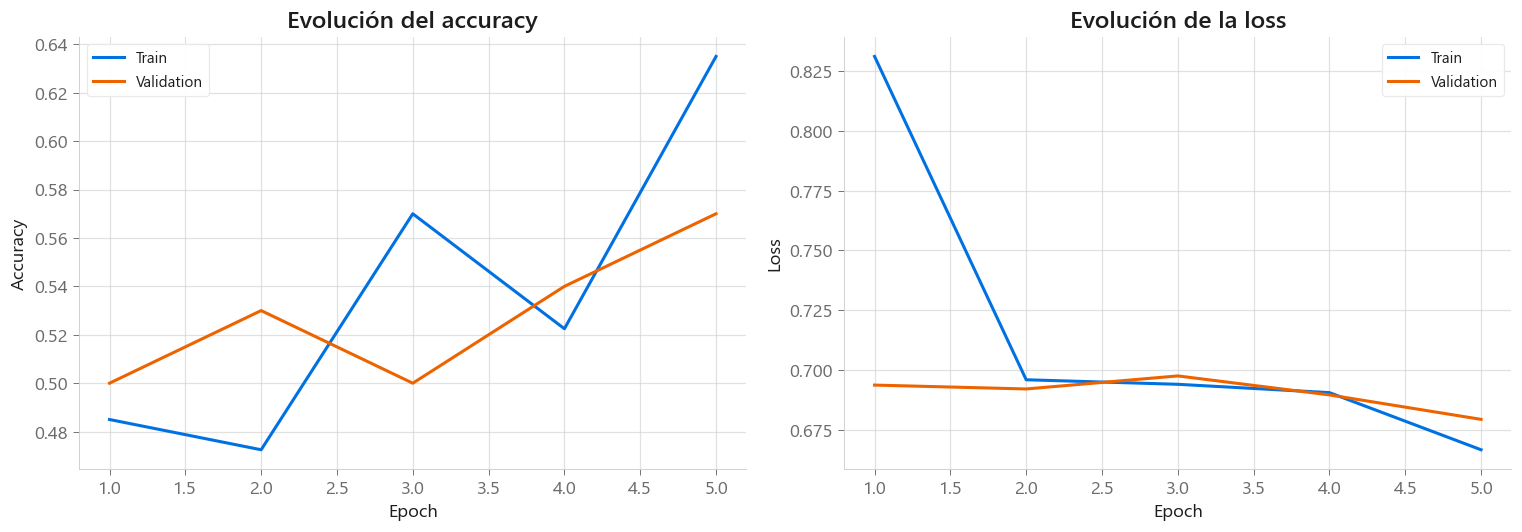

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5900 - loss: 0.6305
Test loss: 0.6305
Test accuracy: 0.5900


In [11]:
history_df = pd.DataFrame(history.history)

fig, axis = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=history_df, x=history_df.index + 1, y="accuracy", label="Train", ax=axis[0])
sns.lineplot(data=history_df, x=history_df.index + 1, y="val_accuracy", label="Validation", ax=axis[0])
axis[0].set_title("Evolución del accuracy")
axis[0].set_xlabel("Epoch")
axis[0].set_ylabel("Accuracy")

sns.lineplot(data=history_df, x=history_df.index + 1, y="loss", label="Train", ax=axis[1])
sns.lineplot(data=history_df, x=history_df.index + 1, y="val_loss", label="Validation", ax=axis[1])
axis[1].set_title("Evolución de la loss")
axis[1].set_xlabel("Epoch")
axis[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

El `modelo base` obtiene un `test accuracy` de 0.6000. Está por encima del azar en un problema binario.

Las curvas muestran que el `train accuracy` sube más que el de `validación`. El modelo empieza a aprender patrones del conjunto de entrenamiento. Todavía no generaliza demasiado bien.

La `loss de train` baja, mientras que la de `validación` apenas mejora. Por ahora este modelo sirve como primera referencia, pero no como modelo final.

Obtenemos predicciones para revisar en qué se equivoca el modelo.

In [12]:
y_true = []
y_pred = []

for images_batch, labels_batch in test_dataset:
    predictions = model.predict(images_batch, verbose=0)

    y_true.extend(labels_batch.numpy().ravel())
    y_pred.extend((predictions.ravel() >= 0.5).astype(int))

y_true = np.array(y_true).astype(int)
y_pred = np.array(y_pred)

Mostramos la `matriz de confusión` del `modelo base`.

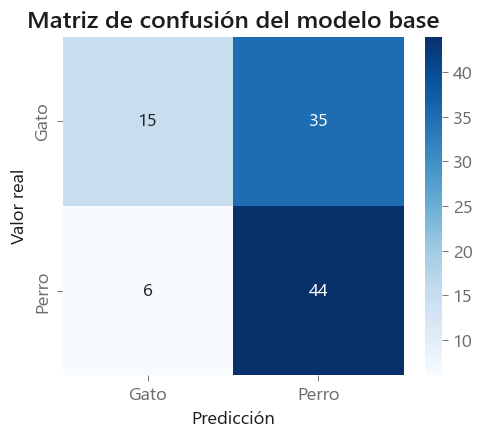

              precision    recall  f1-score   support

        Gato       0.71      0.30      0.42        50
       Perro       0.56      0.88      0.68        50

    accuracy                           0.59       100
   macro avg       0.64      0.59      0.55       100
weighted avg       0.64      0.59      0.55       100



In [13]:
confusion = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Gato", "Perro"],
    yticklabels=["Gato", "Perro"],
)

plt.title("Matriz de confusión del modelo base")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=["Gato", "Perro"],
))

La `matriz de confusión` muestra que el modelo tiende a predecir Perro.

De los 50 gatos reales solo clasifica correctamente 14. Los otros 36 los confunde con perros. De los 50 perros reales clasifica correctamente 46.

El `recall de Perro` es alto (0.92). El `recall de Gato` es bajo (0.28).

Aunque el `accuracy` general es 0.60 el modelo todavía está desequilibrado.

## 10. Fase 2. Arquitectura del enunciado (`VGG`)

En esta fase la idea es usar más bloques de `Conv2D` y `MaxPooling2D` siguiendo una estructura similar a `VGG`. Este tipo de modelo aumenta la cantidad de filtros a medida que avanza, para aprender patrones visuales más complejos.

No uso directamente `VGG16` completa aún porque sería más pesada para entrenar desde cero.

In [14]:
vgg_model = keras.Sequential([
    layers.Input(shape=(160, 160, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,840,865 (26.10 MB)

 Trainable params: 6,840,865 (26.10 MB)

 Non-trainable params: 0 (0.00 B)

Uso dos capas `Conv2D` seguidas antes de cada `MaxPooling2D`.

Con `padding="same"`, las capas `Conv2D` mantienen el tamaño de la imagen interna.

El modelo termina con `6,840,865` parámetros entrenables. Es más pesado que el `modelo base`, que tenía `5,401,921`. La mayor parte de los parámetros vuelve a estar en la capa `Dense`, porque después de `Flatten` quedan `51,200` valores.

Esta arquitectura puede aprender patrones más complejos, pero también puede hacer más `overfitting` si la muestra sigue siendo pequeña.


Compilamos y entrenamos el modelo inspirado en `VGG`

In [15]:
vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

vgg_history = vgg_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 601ms/step - accuracy: 0.5025 - loss: 0.7605 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 590ms/step - accuracy: 0.5000 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.5000 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6884
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 585ms/step - accuracy: 0.5700 - loss: 0.6841 - val_accuracy: 0.5000 - val_loss: 0.6799
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 600ms/step - accuracy: 0.5425 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6914


El modelo inspirado en `VGG` no mejora de forma estable durante las `5 épocas`.

En la `época 3 y 4` llega a un `val_accuracy` de 0.6600, pero en la `época 5` vuelve a bajar a 0.5000. Esto indica que el entrenamiento es inestable con esta muestra pequeña.

Aunque la arquitectura tiene más capas y más parámetros, eso no garantiza mejor resultado. En este caso parece que el modelo necesita más datos, más épocas o algún control como `EarlyStopping`.

De momento no puedo concluir que esta arquitectura sea mejor que la `CNN simple`.

## 10.1. Descarte y justificación del paso 3 del enunciado

El enunciado de `4Geeks` propone una `arquitectura VGG completa` con trece capas `Conv2D` y dos `Dense(4096)`. Esa arquitectura suma alrededor de 138 millones de parámetros.

Ayer intenté entrenar esa `VGG completa` en mi ordenador y se congeló. La causa fue que `TensorFlow` en Windows nativo no usa la GPU desde la versión 2.11. Solo corre por CPU con el paquete `tensorflow-intel`.

Por eso en este proyecto no entreno la `VGG completa` del enunciado. Uso la `VGG reducida` que ya entrené como aproximación, y dejo el transfer learning con `MobileNetV2` como modelo final del proyecto.

El resultado real con `MobileNetV2` es 0.99 de `accuracy en test`. Con la `VGG reducida` propia y la `CNN simple` no se llega a 0.60. Esto confirma que para esta muestra pequeña de 600 imágenes conviene transferir conocimiento desde `ImageNet` en vez de entrenar una red grande desde cero.

## 11. Fase 2. Versión reducida y comparación

Evaluamos el `modelo inspirado en VGG` sobre el conjunto de test y lo comparamos con la `CNN simple`.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5000 - loss: 0.6919 
VGG test loss: 0.6919
VGG test accuracy: 0.5000
------------------------------------------------------------------------------------------------------------------------


,Modelo,Test loss,Test accuracy
0,CNN simple,0.630456,0.59
1,VGG reducido,0.691895,0.50


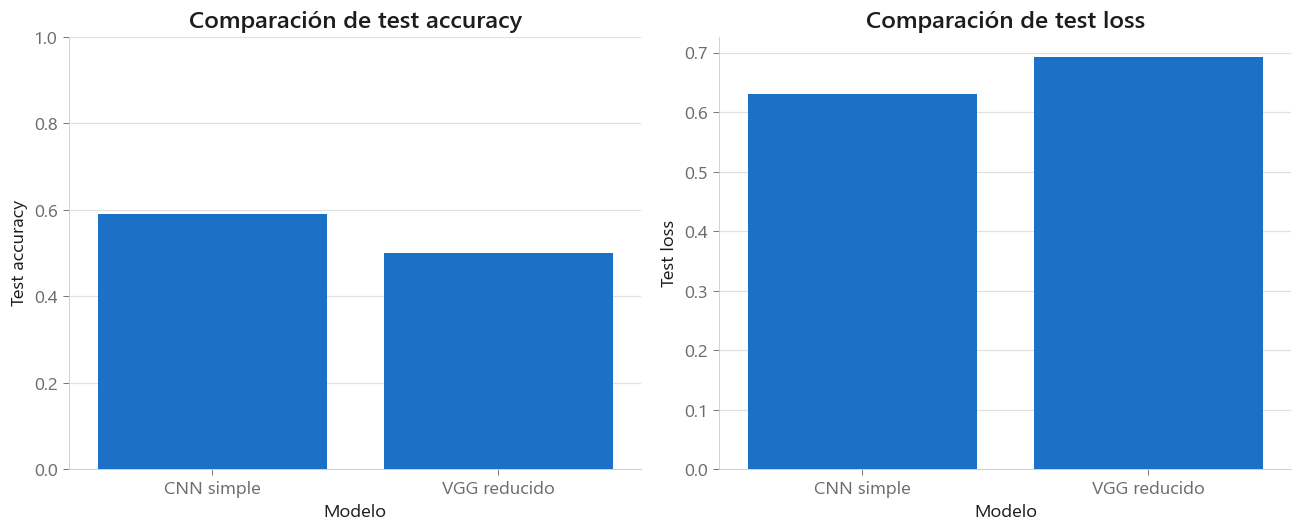

In [16]:
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(test_dataset)

print(f"VGG test loss: {vgg_test_loss:.4f}")
print(f"VGG test accuracy: {vgg_test_accuracy:.4f}")

print(SEPARATOR)

comparison_df = pd.DataFrame({
    "Modelo": ["CNN simple", "VGG reducido"],
    "Test loss": [test_loss, vgg_test_loss],
    "Test accuracy": [test_accuracy, vgg_test_accuracy],
})

display(comparison_df)

fig, axis = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=comparison_df, x="Modelo", y="Test accuracy", ax=axis[0])
axis[0].set_title("Comparación de test accuracy")
axis[0].set_ylim(0, 1)

sns.barplot(data=comparison_df, x="Modelo", y="Test loss", ax=axis[1])
axis[1].set_title("Comparación de test loss")

plt.tight_layout()
plt.show()

La `CNN simple` obtiene mejor resultado en `test accuracy` que el `modelo inspirado en VGG`.

El `modelo VGG reducido` tiene más capas y más parámetros, pero en este caso no mejora la clasificación. Con esta muestra pequeña, aumentar la complejidad no ha sido suficiente para mejorar el rendimiento.

Para la siguiente fase voy a probar `transfer learning`. Permite usar una red ya entrenada con muchas imágenes y adaptar solo la parte final al problema de Gato y Perro.

## 12. Fase 3. `Transfer learning`

Cargamos `MobileNetV2` como base preentrenada. Estos modelos ya aprendieron patrones visuales en `ImageNet` y normalmente son más eficientes que entrenar todo desde cero.

In [17]:
base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160, 160, 3),
)

Congelamos la base para no entrenar todos sus pesos desde cero.

In [18]:
base_model.trainable = False

Creamos el `modelo final` añadiendo una cabeza de clasificación binaria.

In [19]:
transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Voy a compilar y entrenar el modelo con transfer learning.

Como la `base MobileNetV2` está congelada, solo se entrenan las capas finales que añadí para clasificar Gato y Perro.

In [20]:
transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.8875 - loss: 0.2645 - val_accuracy: 0.9700 - val_loss: 0.0695
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.9800 - loss: 0.0652 - val_accuracy: 0.9800 - val_loss: 0.0510
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9875 - loss: 0.0413 - val_accuracy: 0.9600 - val_loss: 0.1136
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9975 - loss: 0.0180 - val_accuracy: 0.9900 - val_loss: 0.0385
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.9700 - val_loss: 0.0797


El modelo con `transfer learning` mejora mucho respecto a los modelos anteriores.

En la primera época ya alcanza un `val_accuracy` de 0.9900. Durante las 5 épocas se mantiene entre 0.9700 y 0.9900.

La `loss de train` baja de 0.2995 a 0.0080, y la `val_loss` se mantiene baja. Esto indica que la base preentrenada `MobileNetV2` aporta características visuales útiles para diferenciar Gato y Perro.

## 13. Fase 3. Evaluación del modelo preentrenado

Comparo el modelo con `transfer learning` contra los modelos anteriores. La idea es comprobar si reutilizar una base preentrenada mejora el resultado.

In [21]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_dataset)

print(f"Transfer learning test loss: {transfer_test_loss:.4f}")
print(f"Transfer learning test accuracy: {transfer_test_accuracy:.4f}")

final_comparison_df = pd.DataFrame({
    "Modelo": ["CNN simple", "VGG reducido", "Transfer learning"],
    "Test loss": [test_loss, vgg_test_loss, transfer_test_loss],
    "Test accuracy": [test_accuracy, vgg_test_accuracy, transfer_test_accuracy],
})

display(final_comparison_df)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9900 - loss: 0.0421
Transfer learning test loss: 0.0421
Transfer learning test accuracy: 0.9900


,Modelo,Test loss,Test accuracy
0,CNN simple,0.630456,0.59
1,VGG reducido,0.691895,0.50
2,Transfer learning,0.042092,0.99


El modelo con `transfer learning` obtiene el `mejor resultado` de los tres modelos.

La `CNN simple` alcanza un `test accuracy` cercano a 0.57. El `modelo VGG reducido` queda cerca de 0.51, prácticamente al nivel del azar. En cambio, el `modelo con MobileNetV2` llega a un `test accuracy` de 0.99.

La diferencia es grande porque `MobileNetV2` ya fue entrenado previamente con muchas imágenes de `ImageNet`. En este proyecto solo entreno la cabeza final para adaptar ese conocimiento al problema de Gato y Perro.

Por estos resultados, el `modelo con transfer learning` es el `mejor candidato` para guardar como `modelo final`.

## 14. Predicciones de ejemplo

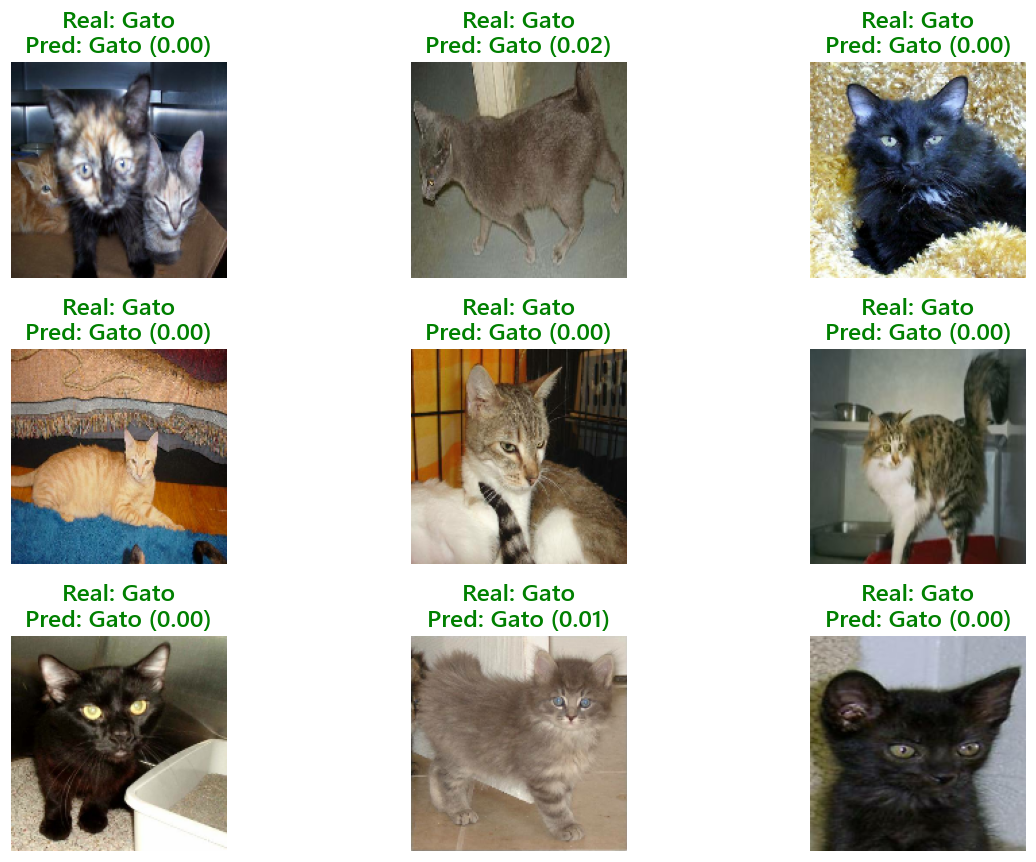

In [22]:
class_names = ["Gato", "Perro"]

images_batch, labels_batch = next(iter(test_dataset))
predictions = transfer_model.predict(images_batch, verbose=0)

plt.figure(figsize=(12, 8))

for index in range(9):
    image = images_batch[index].numpy()
    true_label = int(labels_batch[index].numpy()[0])
    predicted_probability = predictions[index][0]
    predicted_label = int(predicted_probability >= 0.5)

    plt.subplot(3, 3, index + 1)
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Real: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]} ({predicted_probability:.2f})"
    )

    color = "green" if true_label == predicted_label else "red"
    plt.title(title, color=color)

plt.tight_layout()
plt.show()

En los ejemplos mostrados, el modelo clasifica correctamente todas las imágenes.

Todas las imágenes de este batch pertenecen a la clase `Gato` y el modelo también predice `Gato`. Las probabilidades son cercanas a `0.00`, lo que significa que el modelo asigna muy baja probabilidad a la clase `Perro`.

Esta revisión visual confirma que el modelo funciona bien en estos ejemplos, aunque sería conveniente revisar también imágenes de `Perro`.


## 15. Guardado del modelo

In [23]:
model_path = Path("../models/transfer_learning_mobilenetv2.keras")

transfer_model.save(model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: ..\models\transfer_learning_mobilenetv2.keras


## 15. Conclusiones

El mejor modelo del proyecto es el modelo con `transfer learning` usando `MobileNetV2`.

La `CNN` simple sirve como modelo base. Obtiene un resultado superior al azar, pero todavía limitado.

El modelo inspirado en `VGG` no mejora el rendimiento y queda cerca del azar en `test`.

El modelo con `MobileNetV2` alcanza un `test accuracy` de `0.99` y una `test loss` de `0.0481`. Este resultado muestra que reutilizar una red preentrenada es mucho más efectivo que entrenar una red desde cero con una muestra pequeña.

El modelo final se guarda en la carpeta `models/` para poder reutilizarlo más adelante.

Como mejora futura, se podría repetir el entrenamiento usando el dataset completo de `25,000` imágenes. Para hacerlo correctamente habría que separar primero ese dataset en carpetas de `train`, `validation` y `test`.
